# 01 — Data Preparation

Implements the paper's Amazon e-commerce data preparation:
- Clean and standardize columns
- Compute per-purchase state features (routine, recency, novelty, affinity, popularity)
- Build choice sets: 1 positive + 9 negatives (half same-category, half random)
- Temporal train / val / test split (per-customer)
- Save processed outputs to `data/`

In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import pickle
from pathlib import Path

from src.data_prep import load_data, clean_purchases, compute_state_features, build_choice_sets, temporal_split

DATA_DIR = Path('../amazon_ecom')
OUT_DIR = Path('../data')
OUT_DIR.mkdir(exist_ok=True)

## 1. Load and clean

In [3]:
purchases_raw, survey = load_data()
df = clean_purchases(purchases_raw)
print(f'Cleaned purchases: {len(df):,} rows  |  {df["customer_id"].nunique():,} customers')
df.dtypes

Cleaned purchases: 1,849,744 rows  |  5,023 customers


order_date     datetime64[us]
price                 float64
quantity              float64
state                     str
title                     str
asin                      str
category                  str
customer_id               str
dtype: object

## 2. Compute state features

In [4]:
df = compute_state_features(df)
print('New columns:', [c for c in df.columns if c not in purchases_raw.columns])
df[['customer_id', 'asin', 'order_date', 'routine', 'recency_days', 'novelty', 'cat_affinity', 'popularity']].head(10)

New columns: ['order_date', 'price', 'quantity', 'state', 'title', 'asin', 'category', 'customer_id', 'routine', 'novelty', 'last_purchase_date', 'recency_days', 'cat_affinity', 'cat_count_7d', 'cat_count_30d', 'popularity', 'brand']


,customer_id,asin,order_date,routine,recency_days,novelty,cat_affinity,popularity
0,R_01vNIayewjIIKMF,B0143RTB1E,2018-12-04,0,999.0,1,0,11
1,R_01vNIayewjIIKMF,B01MA1MJ6H,2018-12-22,0,999.0,1,0,23
2,R_01vNIayewjIIKMF,B078JZTFN3,2018-12-24,0,999.0,1,0,1
3,R_01vNIayewjIIKMF,B06XWF9HML,2018-12-25,0,999.0,1,0,1
4,R_01vNIayewjIIKMF,B00837ZOI0,2018-12-25,0,999.0,1,0,6
5,R_01vNIayewjIIKMF,B01GFB2E9M,2019-02-18,0,999.0,1,0,6
6,R_01vNIayewjIIKMF,B00NH13S44,2019-02-18,0,999.0,1,0,32
7,R_01vNIayewjIIKMF,B077H6L7T9,2019-03-15,0,999.0,1,0,2
8,R_01vNIayewjIIKMF,B07L84ZZXC,2019-04-23,0,999.0,1,0,1
9,R_01vNIayewjIIKMF,B06XKNWJN2,2019-04-23,0,999.0,1,1,7


## 3. Filter customers with enough history

Keep customers with ≥ 5 purchases so we have meaningful train/val/test splits.

In [5]:
MIN_PURCHASES = 5
counts = df['customer_id'].value_counts()
valid_customers = counts[counts >= MIN_PURCHASES].index
df = df[df['customer_id'].isin(valid_customers)].reset_index(drop=True)
print(f'After filtering: {len(df):,} purchases from {df["customer_id"].nunique():,} customers')

After filtering: 1,849,635 purchases from 4,986 customers


## 4. Train / val / test split (temporal, per-customer)

In [6]:
df = temporal_split(df, val_frac=0.1, test_frac=0.1)
print(df['split'].value_counts())

split
train    1484093
val       182771
test      182771
Name: count, dtype: int64


## 4b. subsample diverse customers (optional speedup)

uses leverage-score sampling to pick a behaviorally diverse subset of customers.
selected customers get importance weights so the objective still approximates the full thing.
set `SUBSAMPLE_CUSTOMERS` to `None` to skip this.

In [7]:
from src.subsample import subsample_customers, apply_subsample

SUBSAMPLE_CUSTOMERS = 500  # set to None to use all customers

if SUBSAMPLE_CUSTOMERS is not None:
    train_df_full = df[df['split'] == 'train'].reset_index(drop=True)
    selected_ids, customer_weights = subsample_customers(
        train_df_full,
        n_customers=SUBSAMPLE_CUSTOMERS,
        seed=42,
    )
    train_df_sub, event_weight_map = apply_subsample(train_df_full, selected_ids, customer_weights)
    print(f'subsampled: {len(selected_ids)} customers, {len(train_df_sub)} events')
    print(f'  from {train_df_full["customer_id"].nunique()} customers, {len(train_df_full)} events')
    print(f'  weight range: [{min(customer_weights):.2f}, {max(customer_weights):.2f}]')
    print(f'  weight sum: {sum(customer_weights):.0f} (should be ~{train_df_full["customer_id"].nunique()})')
else:
    train_df_sub = None
    event_weight_map = None
    print('no subsampling, using all customers')

subsampled: 500 customers, 119299 events
  from 4986 customers, 1484093 events
  weight range: [0.12, 70.79]
  weight sum: 4986 (should be ~4986)


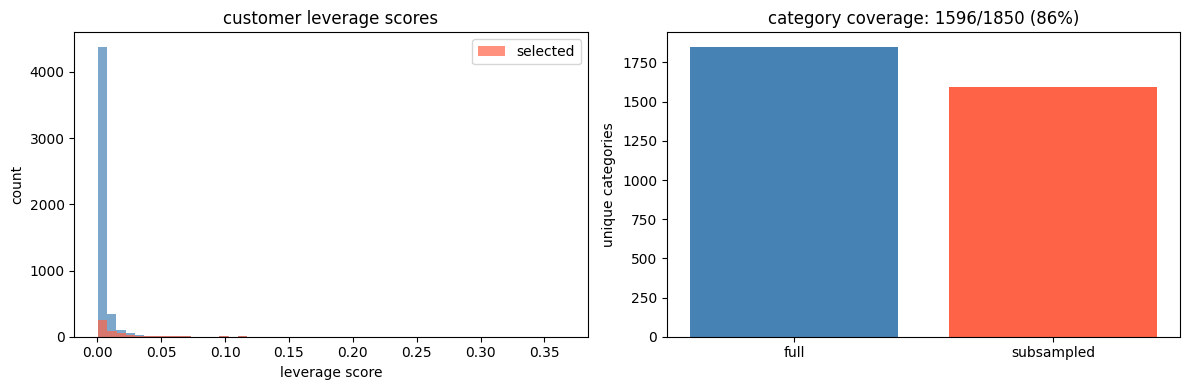

In [8]:
if SUBSAMPLE_CUSTOMERS is not None:
    import matplotlib.pyplot as plt
    from src.subsample import build_customer_profiles, compute_leverage_scores

    profiles_df, profile_matrix = build_customer_profiles(train_df_full)
    leverage = compute_leverage_scores(profile_matrix)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # leverage distribution -- red = selected customers
    axes[0].hist(leverage, bins=50, color='steelblue', alpha=0.7)
    selected_mask = profiles_df.index.isin(selected_ids)
    axes[0].hist(leverage[selected_mask], bins=50, color='tomato', alpha=0.7, label='selected')
    axes[0].set_xlabel('leverage score')
    axes[0].set_ylabel('count')
    axes[0].set_title('customer leverage scores')
    axes[0].legend()

    # how many categories did we keep
    all_cats = train_df_full['category'].nunique()
    sub_cats = train_df_sub['category'].nunique()
    axes[1].bar(['full', 'subsampled'], [all_cats, sub_cats], color=['steelblue', 'tomato'])
    axes[1].set_ylabel('unique categories')
    axes[1].set_title(f'category coverage: {sub_cats}/{all_cats} ({100*sub_cats/all_cats:.0f}%)')

    plt.tight_layout()
    plt.show()

## 5. Build choice sets

For each purchase event: 1 positive + 9 negatives (5 same-category + 4 random).
This creates the (s_t, A(s_t), a*) tuples for the conditional logit.

In [9]:
# use subsampled df if we have it, otherwise full training set
if train_df_sub is not None:
    train_df = train_df_sub
else:
    train_df = df[df['split'] == 'train'].reset_index(drop=True)
print(f'building choice sets for {len(train_df):,} training events...')
train_choices = build_choice_sets(train_df, n_negatives=9)
print(f'choice sets built: {len(train_choices):,}')
ex = train_choices[0]
print(f'  chosen_asin={ex["chosen_asin"]}, chosen_idx={ex["chosen_idx"]}, n_alts={len(ex["choice_asins"])}')

building choice sets for 119,299 training events...
choice sets built: 119,299
  chosen_asin=B00H2BBA2C, chosen_idx=1, n_alts=10


In [10]:
val_df  = df[df['split'] == 'val'].reset_index(drop=True)
test_df = df[df['split'] == 'test'].reset_index(drop=True)
val_choices  = build_choice_sets(val_df,  n_negatives=9)
test_choices = build_choice_sets(test_df, n_negatives=9)
print(f'Val:  {len(val_choices):,} events')
print(f'Test: {len(test_choices):,} events')

KeyboardInterrupt: 

## 6. Save processed data

In [ ]:
df.to_parquet(OUT_DIR / 'purchases_processed.parquet', index=False)
with open(OUT_DIR / 'train_choices.pkl', 'wb') as f:
    pickle.dump(train_choices, f)
with open(OUT_DIR / 'val_choices.pkl', 'wb') as f:
    pickle.dump(val_choices, f)
with open(OUT_DIR / 'test_choices.pkl', 'wb') as f:
    pickle.dump(test_choices, f)

# save event weights if we subsampled
if event_weight_map is not None:
    with open(OUT_DIR / 'event_weight_map.pkl', 'wb') as f:
        pickle.dump(event_weight_map, f)
    print(f'  event_weight_map.pkl  ({len(event_weight_map)} customers)')

print('saved to data/')
print(f'  purchases_processed.parquet  ({df.shape})')
print(f'  train_choices.pkl  ({len(train_choices):,} events)')
print(f'  val_choices.pkl    ({len(val_choices):,} events)')
print(f'  test_choices.pkl   ({len(test_choices):,} events)')

NameError: name 'df' is not defined